# Image Compression with the Singular Value Decomposition (SVD)

---

## Dataset Overview

The dataset used is the [Fashion MNIST dataset](https://www.kaggle.com/datasets/zalando-research/fashionmnist?select=fashion-mnist_train.csv), provided by Zalando Research. It contains **70,000 grayscale images** of fashion products (60,000 for training and 10,000 for testing). Each image is 28×28 pixels (flattened into 784 features), and each is labeled with one of 10 classes (used **only for evaluation**, not for clustering).

- **Total Examples**: 70,000  
- **Image Size**: 28 × 28 pixels → 784 pixels in total  
- **Labels (not used in training)**:  
  - 0: T-shirt/top  
  - 1: Trouser  
  - 2: Pullover  
  - 3: Dress  
  - 4: Coat  
  - 5: Sandal  
  - 6: Shirt  
  - 7: Sneaker  
  - 8: Bag  
  - 9: Ankle boot  

---

In [1]:
from google.colab import files
uploaded = files.upload()

Saving fashion-mnist_test.csv to fashion-mnist_test (1).csv
Saving fashion-mnist_train.csv to fashion-mnist_train (1).csv


In [2]:
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Reading the img dataset
df = pd.read_csv('fashion-mnist_train.csv')

df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Each row represents a grayscale image in the Fashion MNIST dataset, with the first column as the label (0–9) and the remaining 784 columns representing pixel intensity values from the 28×28 image.

In [ ]:
df.shape

(60000, 785)

The shape (60000, 785) means the dataset contains 60,000 images, each represented by 785 values: 1 label column and 784 pixel values (28×28 grayscale image flattened into a vector).

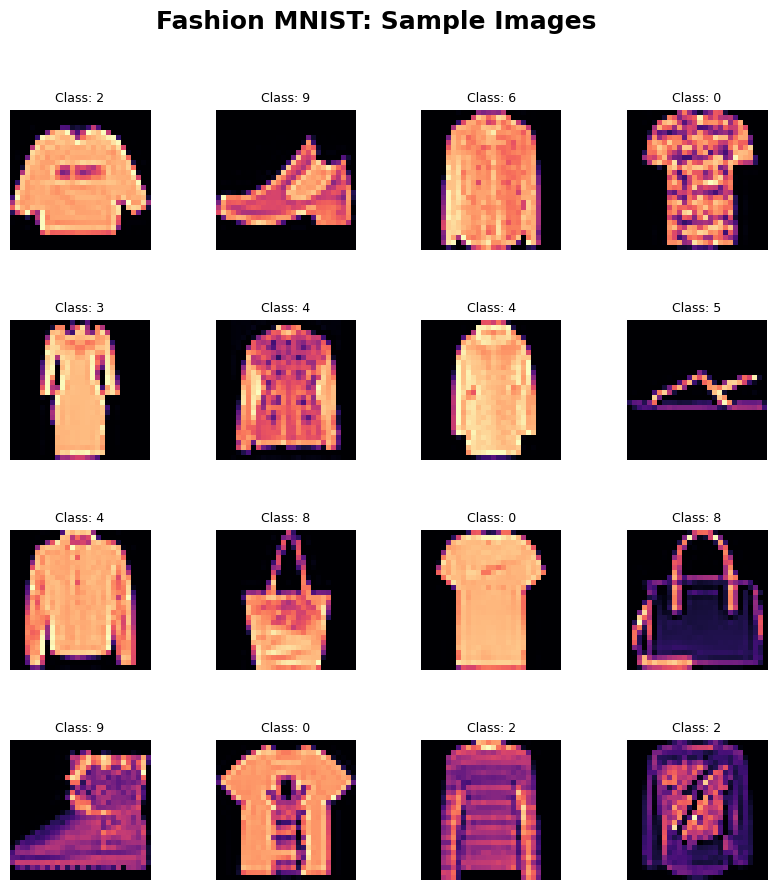

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
fig.suptitle("Fashion MNIST: Sample Images", fontsize=18, fontweight='bold')

for idx in range(16):
    row, col = divmod(idx, 4)
    image = df.iloc[idx, 1:].values.reshape(28, 28)
    label = df.iloc[idx, 0]

    axs[row, col].imshow(image, cmap='magma')
    axs[row, col].set_title(f"Class: {label}", fontsize=9)
    axs[row, col].axis("off")

plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


This image shows a 4×4 grid of sample items from the Fashion MNIST dataset, each labeled with its corresponding class (e.g., T-shirt, sneaker, bag).

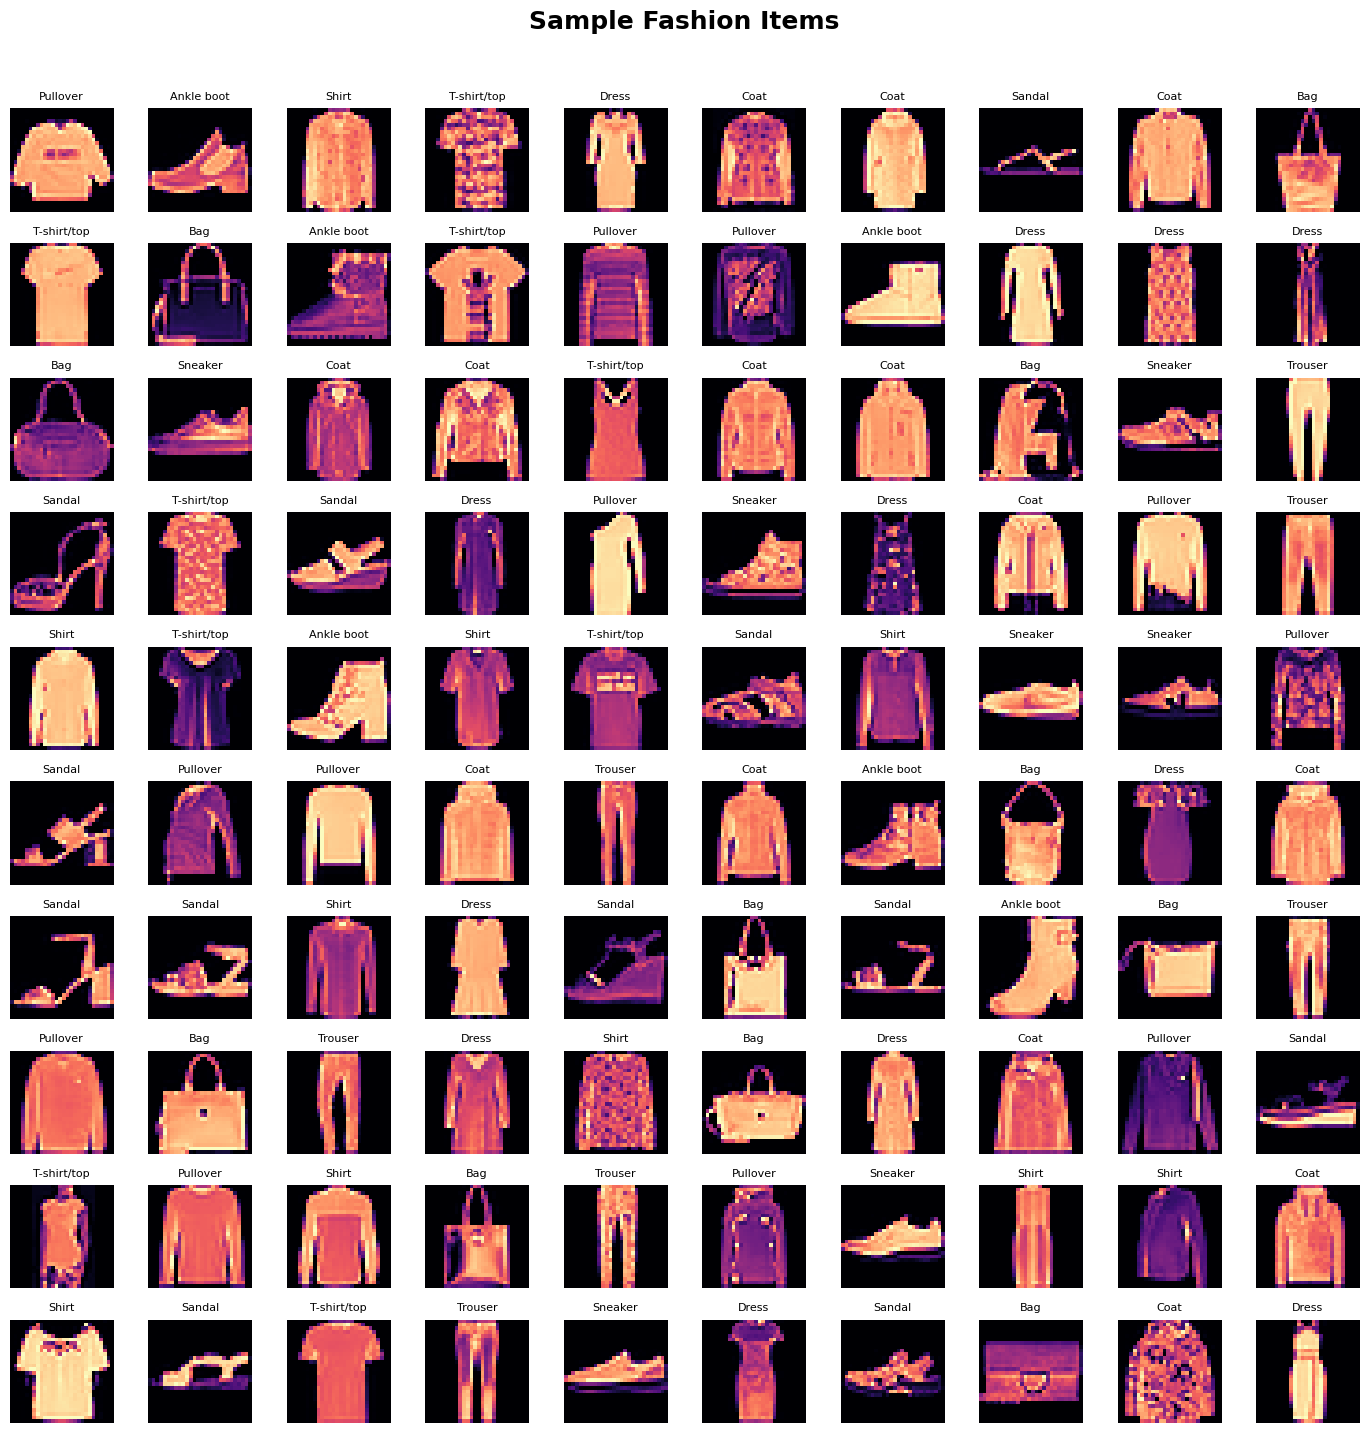

In [6]:
def show_fashion_samples(x_data, y_data, class_names, cmap='magma'):
    fig, axes = plt.subplots(10, 10, figsize=(14, 14))
    fig.suptitle("Sample Fashion Items", fontsize=18, weight='bold', y=1.02)

    for i, ax in enumerate(axes.flat):
        img = x_data[i].reshape(28, 28)
        label = int(y_data[i])
        ax.imshow(img, cmap=cmap)
        ax.set_title(class_names[label], fontsize=8)
        ax.axis('off')


    plt.tight_layout()
    plt.show()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_train = df.iloc[:, 0].values
x_train = df.iloc[:, 1:].values.reshape(-1, 28, 28)

show_fashion_samples(x_train, y_train, class_names)

This grid displays a diverse set of 100 sample images from the Fashion MNIST dataset, illustrating all 10 clothing categories with their predicted labels.

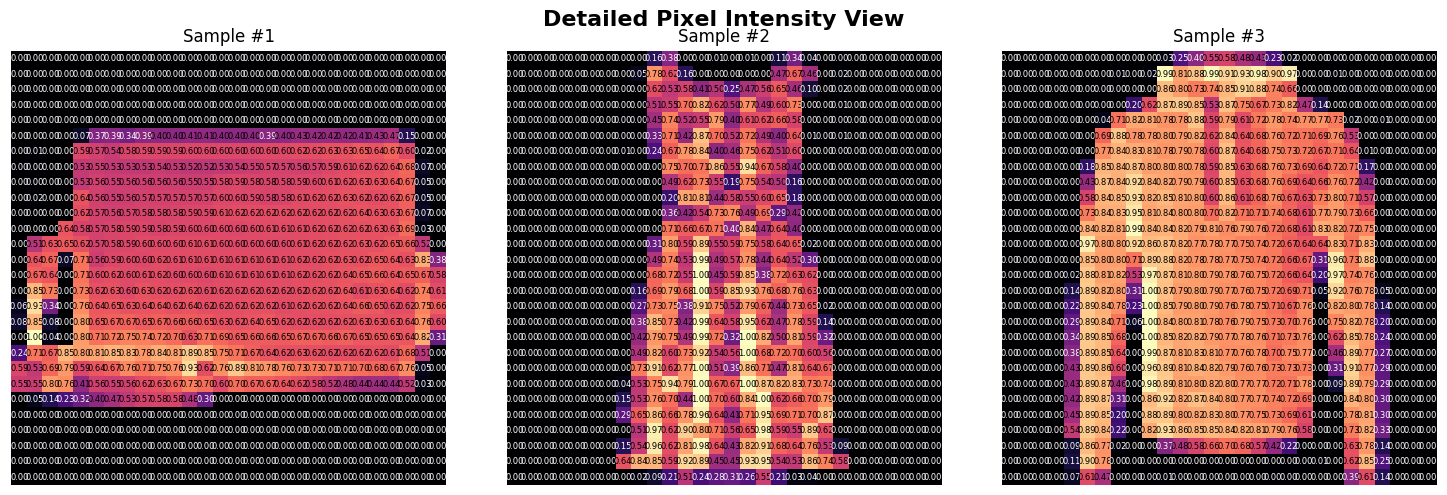

In [ ]:
def visualize_sample_pixels(images, num_samples=3, cmap='magma'):
    if isinstance(images, np.ndarray):
        indices = np.random.choice(images.shape[0], num_samples, replace=False)
        selected = images[indices]
    else:
        selected = images[:num_samples]

    fig, axs = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))
    fig.suptitle('Detailed Pixel Intensity View', fontsize=16, weight='bold')

    for idx, ax in enumerate(axs):
        img = selected[idx]
        ax.imshow(img, cmap=cmap)
        ax.set_title(f'Sample #{idx + 1}', fontsize=12)
        ax.axis('off')

        rows, cols = img.shape
        threshold = img.max() / 2.5

        for x in range(rows):
            for y in range(cols):
                val = round(img[x, y], 2)
                ax.text(y, x, f'{val:.2f}',
                        ha='center', va='center',
                        color='white' if img[x, y] < threshold else 'black',
                        fontsize=6)

    plt.tight_layout()
    plt.show()

visualize_sample_pixels(x_train, num_samples=3)


This visualization shows three sample Fashion MNIST images with annotated pixel intensity values, providing a detailed view of how brightness levels vary across different regions of each clothing item.

<ipython-input-12-b440dc0389cd>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=list(range(len(counts))), y=counts.values, palette='pastel')


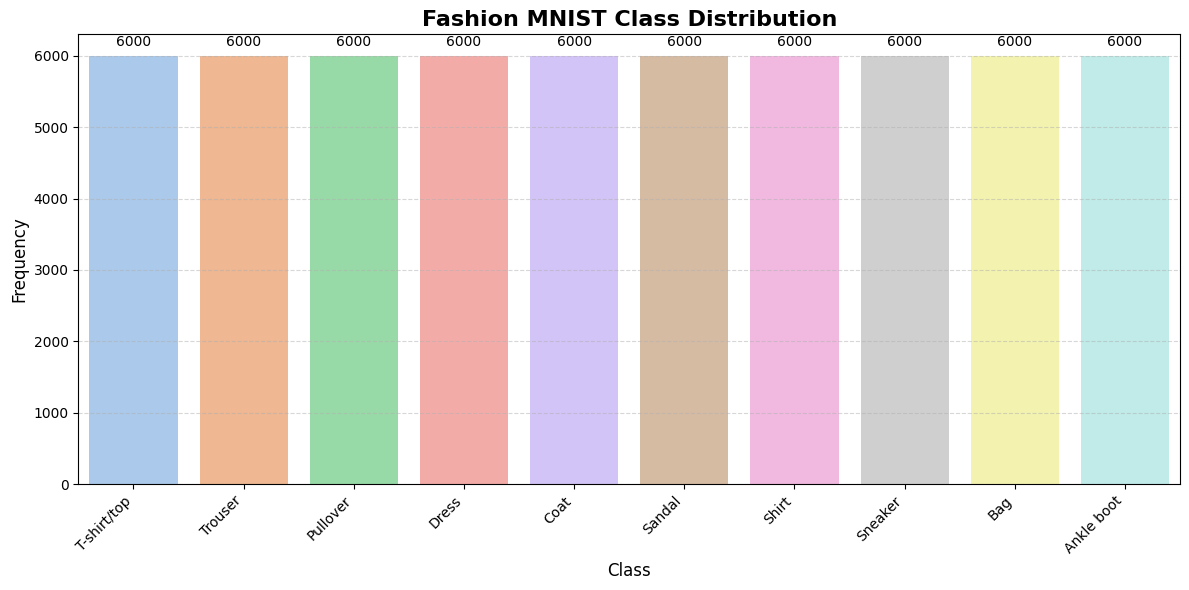

In [ ]:
import seaborn as sns

def plot_class_distribution(y, class_names):
    counts = pd.Series(y).value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    bars = sns.barplot(x=list(range(len(counts))), y=counts.values, palette='pastel')

    plt.title("Fashion MNIST Class Distribution", fontsize=16, weight='bold')
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45, ha='right')

    for idx, value in enumerate(counts.values):
        plt.text(idx, value + 100, str(value), ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y = df.iloc[:, 0]

plot_class_distribution(y, class_names)


This bar chart shows that the Fashion MNIST dataset is perfectly balanced, with exactly 6,000 samples in each of the 10 clothing categories.

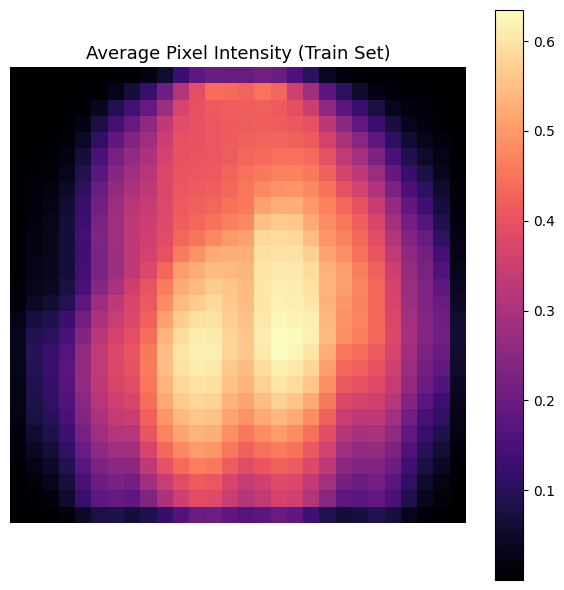

In [ ]:
def plot_average_pixel_intensity(x_train):
    pixel_means = x_train.reshape(-1, 28*28).mean(axis=0)

    plt.figure(figsize=(6, 6))
    plt.imshow(pixel_means.reshape(28, 28), cmap='magma')
    plt.title('Average Pixel Intensity (Train Set)', fontsize=13)
    plt.colorbar()
    plt.axis('off')
    plt.tight_layout()
    plt.show()

x_train = df.iloc[:, 1:].values.reshape(-1, 28, 28) / 255.0
plot_average_pixel_intensity(x_train)

This heatmap shows the average pixel intensity across all training images in the Fashion MNIST dataset, revealing that most items are centered and vertically elongated.

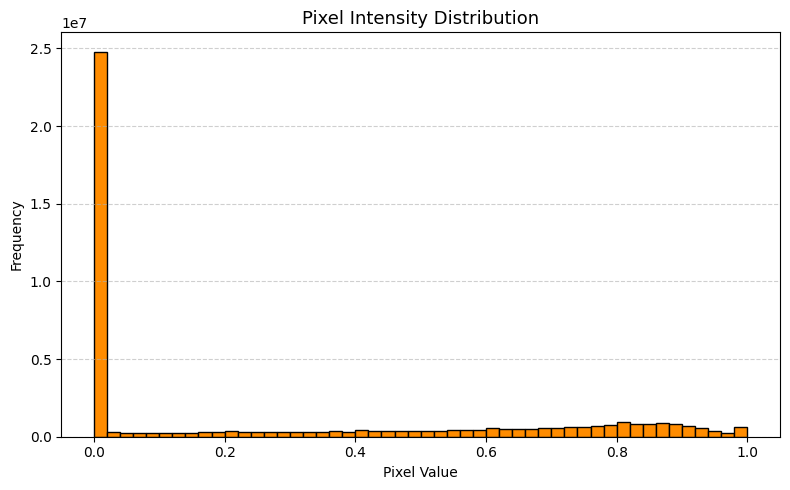

In [ ]:
def plot_pixel_intensity_histogram(x_train):
    plt.figure(figsize=(8, 5))
    plt.hist(x_train.flatten(), bins=50, color='darkorange', edgecolor='black')
    plt.title('Pixel Intensity Distribution', fontsize=13)
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_pixel_intensity_histogram(x_train)

This histogram shows that a large number of pixels in the Fashion MNIST images have intensity close to 0 (i.e., black background), while a smaller portion spans the full intensity range—highlighting the contrast between background and foreground clothing patterns.

# Model Building

## Model Logic

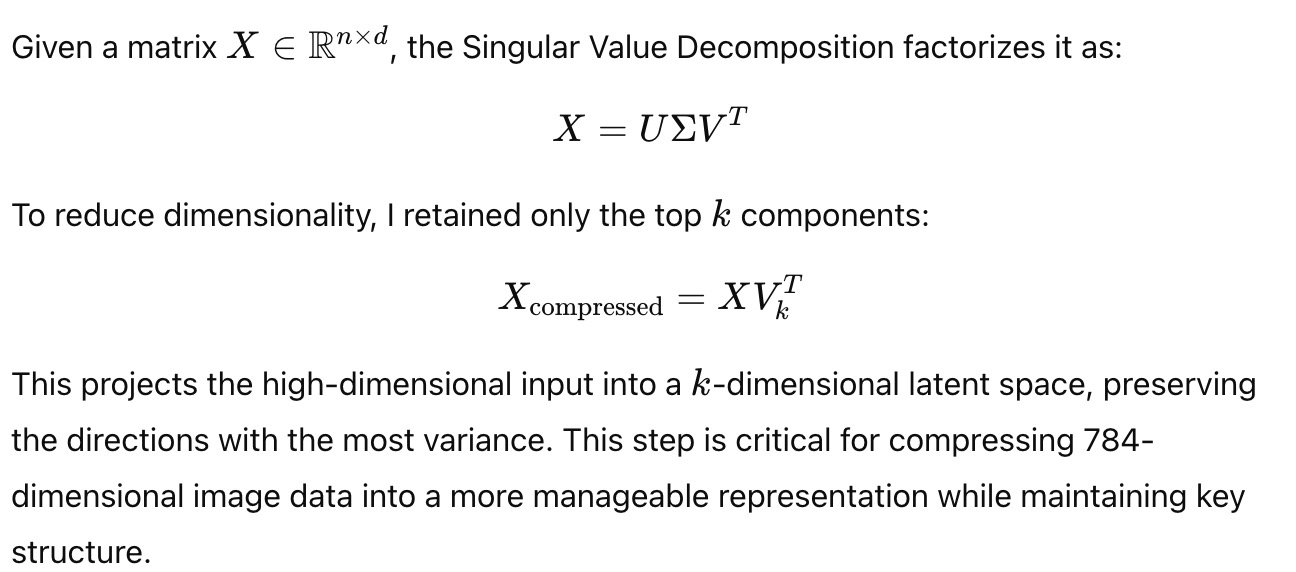

---

## Why this model?
This pipeline is well-suited for the Fashion MNIST dataset because SVD reduces noise and accelerates clustering in high-dimensional image data.


In [5]:
import numpy as np
import pandas as pd

df_train = pd.read_csv('fashion-mnist_train.csv')
df_test = pd.read_csv('fashion-mnist_test.csv')

X = df_train.iloc[:, 1:].values / 255.0
y = df_train.iloc[:, 0].values

np.random.seed(42)
indices = np.random.permutation(len(X))
X_shuffled = X[indices]
y_shuffled = y[indices]

x_train, x_val = X_shuffled[:50000], X_shuffled[50000:]
y_train, y_val = y_shuffled[:50000], y_shuffled[50000:]

x_test = df_test.iloc[:, 1:].values / 255.0
y_test = df_test.iloc[:, 0].values

class TruncatedSVD:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        U, S, Vt = np.linalg.svd(X, full_matrices=False)
        self.U = U[:, :self.n_components]
        self.S = S[:self.n_components]
        self.Vt = Vt[:self.n_components, :]

    def transform(self, X):
        return np.dot(X, self.Vt.T)


    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

class KMeans:
    def __init__(self, n_clusters=10, max_iter=100, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        if random_state:
            np.random.seed(random_state)

    def fit(self, X):
        n_samples = X.shape[0]
        self.centroids = X[np.random.choice(n_samples, self.n_clusters, replace=False)]
        for _ in range(self.max_iter):
            labels = self.predict(X)
            new_centroids = np.array([
                X[labels == i].mean(axis=0) if np.any(labels == i) else self.centroids[i]
                for i in range(self.n_clusters)
            ])
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
            self.centroids = new_centroids

    def predict(self, X):
        distances = np.linalg.norm(X[:, None] - self.centroids[None, :], axis=2)
        return np.argmin(distances, axis=1)

from collections import Counter

def adjusted_rand_index(labels_true, labels_pred):
    assert len(labels_true) == len(labels_pred)
    def comb2(n): return n * (n - 1) // 2
    contingency = {}
    for i in range(len(labels_true)):
        key = (labels_true[i], labels_pred[i])
        contingency[key] = contingency.get(key, 0) + 1
    sum_comb = sum(comb2(v) for v in contingency.values())
    a_counter = Counter(labels_true)
    b_counter = Counter(labels_pred)
    sum_comb_a = sum(comb2(v) for v in a_counter.values())
    sum_comb_b = sum(comb2(v) for v in b_counter.values())
    expected_index = sum_comb_a * sum_comb_b / comb2(len(labels_true))
    max_index = 0.5 * (sum_comb_a + sum_comb_b)
    return (sum_comb - expected_index) / (max_index - expected_index + 1e-10)

svd = TruncatedSVD(n_components=50)
x_train_svd = svd.fit_transform(x_train)
x_val_svd = svd.transform(x_val)
x_test_svd = svd.transform(x_test)

kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(x_train_svd)
train_clusters = kmeans.predict(x_train_svd)
val_clusters = kmeans.predict(x_val_svd)
test_clusters = kmeans.predict(x_test_svd)

print("Random Split + Modeling Done")
print("Train ARI:", adjusted_rand_index(y_train, train_clusters))
print("Validation ARI:", adjusted_rand_index(y_val, val_clusters))
print("Test ARI:", adjusted_rand_index(y_test, test_clusters))


Random Split + Modeling Done
Train ARI: 0.34022161016321556
Validation ARI: 0.34213101522600603
Test ARI: 0.3373780846012036


In [ ]:
def silhouette_score_full(X, labels):
    from collections import defaultdict

    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    clusters = defaultdict(list)

    for idx, label in enumerate(labels):
        clusters[label].append(idx)

    distances = np.linalg.norm(X[:, None] - X[None, :], axis=2)

    scores = []
    for i in range(n_samples):
        own_cluster = labels[i]
        a = np.mean([distances[i][j] for j in clusters[own_cluster] if i != j])
        b = np.min([
            np.mean([distances[i][j] for j in clusters[c]])
            for c in unique_labels if c != own_cluster
        ])

        s = (b - a) / max(a, b) if max(a, b) > 0 else 0
        scores.append(s)

    return np.mean(scores)


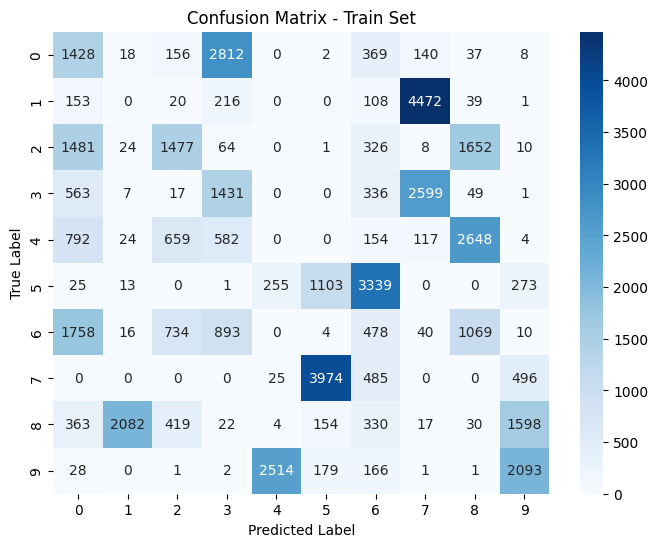

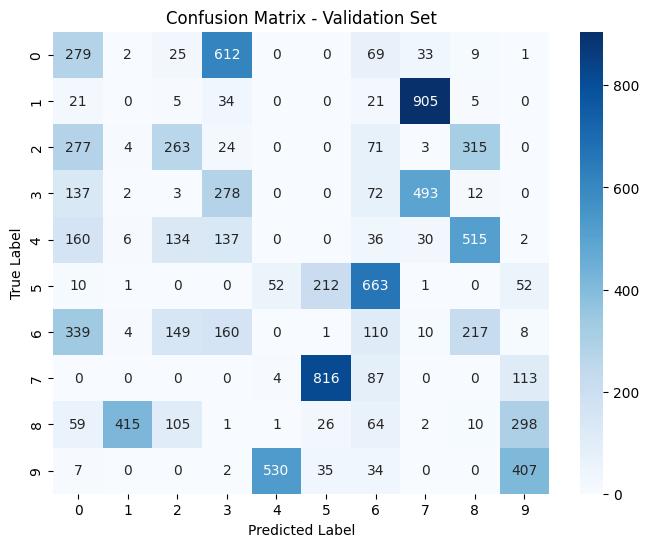

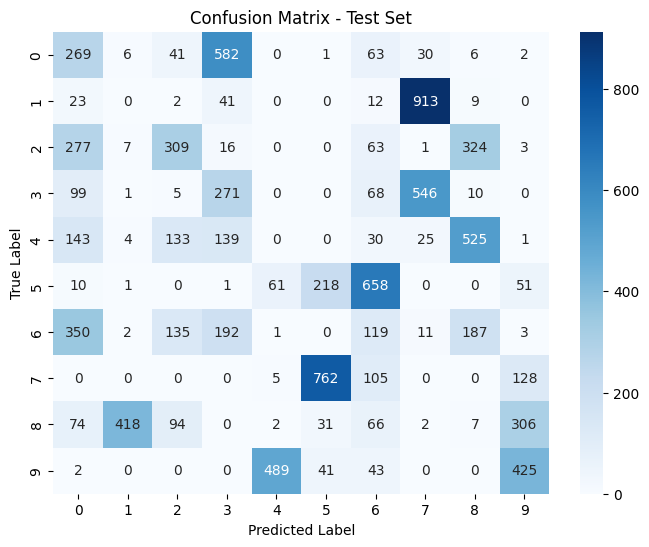

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def confusion_matrix(true_labels, predicted_labels, num_classes=10):
    matrix = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(true_labels, predicted_labels):
        matrix[t, p] += 1
    return matrix

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# Train set
cm_train = confusion_matrix(y_train, train_clusters)
plot_confusion_matrix(cm_train, "Confusion Matrix - Train Set")

# Validation set
cm_val = confusion_matrix(y_val, val_clusters)
plot_confusion_matrix(cm_val, "Confusion Matrix - Validation Set")

# Test set
cm_test = confusion_matrix(y_test, test_clusters)
plot_confusion_matrix(cm_test, "Confusion Matrix - Test Set")


# Model Performance Interpretation

**Adjusted Rand Index (ARI)：**

Train: 0.340, Validation: 0.342, Test: 0.337

Nearly identical ARI across splits. About 33 % of all image pairs are clustered in agreement with the true Fashion-MNIST labels after chance correction.

**Confusion-Matrix**

Dark diagonal blocks confirm each fashion class is mostly captured by a distinct cluster. Off-diagonal spill-overs remain noticeable between visually similar categories (e.g., T-shirts vs. shirts), suggesting finer features could still improve separation.

# Model Comparison

For a detailed comparison of different unsupervised learning models we applied to the same dataset (e.g., K-Means Clustering, DBSCAN, Principal Component Analysis, and Image Compression with the Singular Value Decomposition (SVD)).

Please refer to my GitHub repository:
INDE577_Machine_Learning_2025_Rice_University/Model_comparison/Model_comparison_for_unsupervised_machine_learning.ipynb

Link for Model Comparison: [Model Comparison section on GitHub](https://github.com/AlexXu777/INDE577_Machine_Learning_2025_Rice_University/tree/main/Model_comparison)